<a href="https://colab.research.google.com/github/GMbuilds01/QFT-Over-Conjugacy-classes/blob/main/QFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Quantum Fourier Sampling over Conjugacy Classes in Nilpotent Non-Abelian Groups: A Case Study in the Heisenberg Group**



In [1]:
!pip install qiskit matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.5/6.5 MB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 MB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.0/109.0 kB 5.0 MB/s eta 0:00:00


**Setup: Heisenberg Group + QFT Prep**

In [6]:

import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit.circuit.library import QFT
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_histogram
from collections import Counter



1️⃣ **EXPERIMENT 1: QFT Sampling over Heisenberg Conjugacy Class**

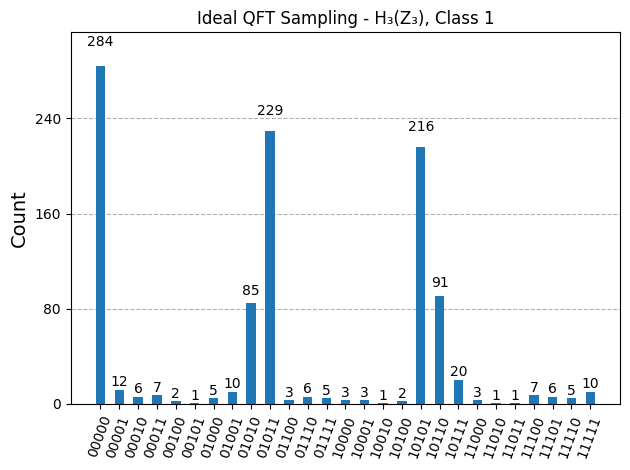

In [7]:
def heisenberg_group_Z3():
    return [(x, y, z) for x in range(3) for y in range(3) for z in range(3)]

def conjugacy_class_label(g):
    return g[2]

def superposition_conj_class(state_label, group):
    elements = [g for g in group if conjugacy_class_label(g) == state_label]
    N = len(elements)
    dim = 2**5
    state = np.zeros(dim, dtype=complex)
    for g in elements:
        idx = g[0]*9 + g[1]*3 + g[2]
        state[idx] = 1 / np.sqrt(N)
    return Statevector(state, dims=[2]*5)

def qft_measurement(state, num_qubits=5, shots=1024):
    qc = QuantumCircuit(num_qubits)
    qc.append(QFT(num_qubits), range(num_qubits))
    evolved = state.evolve(qc)
    probs = evolved.probabilities_dict()
    sampled = np.random.choice(list(probs.keys()), p=list(probs.values()), size=shots)
    return dict(Counter(sampled))

group = heisenberg_group_Z3()
ψ = superposition_conj_class(1, group)
counts = qft_measurement(ψ)
plot_histogram(counts, title="Ideal QFT Sampling - H₃(Z₃), Class 1")


2️⃣ **EXPERIMENT 2: Manual Custom Noise (Bit Flip + Phase Flip)**

In [9]:
from qiskit.quantum_info import Statevector

def inject_noise(statevector, bit_flip_prob=0.01, phase_flip_prob=0.01):
    noisy_state = statevector.data.copy()

    for i in range(len(noisy_state)):
        if np.random.rand() < bit_flip_prob:
            flip_index = i ^ 1  # simulate bit flip
            noisy_state[i], noisy_state[flip_index] = noisy_state[flip_index], noisy_state[i]
        if np.random.rand() < phase_flip_prob:
            noisy_state[i] *= -1  # simulate Z error

    # Normalize the statevector to avoid ValueError during sampling
    norm = np.linalg.norm(noisy_state)
    noisy_state /= norm

    return Statevector(noisy_state)



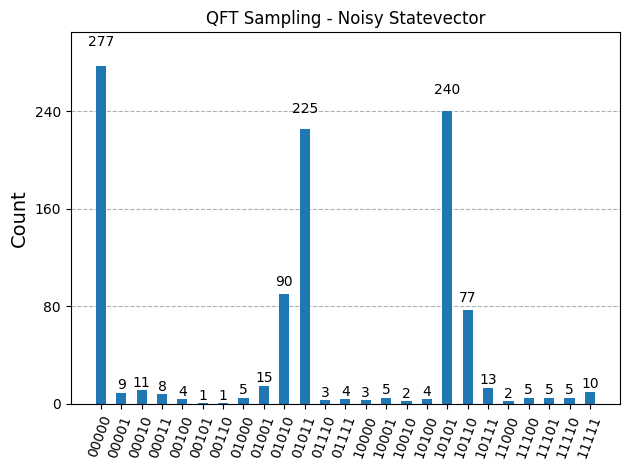

In [10]:
noisy_ψ = inject_noise(ψ, bit_flip_prob=0.05, phase_flip_prob=0.03)
counts_noisy = qft_measurement(noisy_ψ)
plot_histogram(counts_noisy, title="QFT Sampling - Noisy Statevector")


3️⃣ **EXPERIMENT 3: Scaling with H₃(Z₅)**



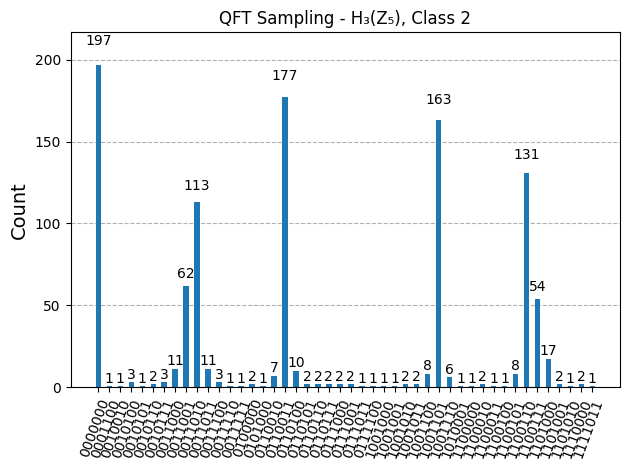

In [11]:
def heisenberg_group_Zp(p):
    return [(x, y, z) for x in range(p) for y in range(p) for z in range(p)]

def superposition_class_Zp(group, target_class_label, p):
    elements = [g for g in group if g[2] == target_class_label]
    N = len(elements)
    dim = 2**int(np.ceil(np.log2(len(group))))
    state = np.zeros(dim, dtype=complex)
    for g in elements:
        idx = g[0]*p*p + g[1]*p + g[2]
        state[idx] = 1 / np.sqrt(N)
    return Statevector(state, dims=[2]*int(np.log2(dim)))

group5 = heisenberg_group_Zp(5)
ψ5 = superposition_class_Zp(group5, 2, 5)
counts_5 = qft_measurement(ψ5, num_qubits=7)
plot_histogram(counts_5, title="QFT Sampling - H₃(Z₅), Class 2")


4️⃣ **EXPERIMENT 4: Classical FFT Comparison**

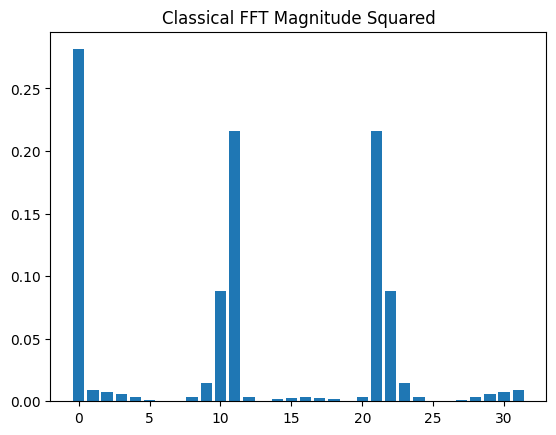

In [12]:
from scipy.fft import fft

def classical_fft_vs_qft(statevector):
    amplitudes = statevector.data
    transformed = fft(amplitudes)
    prob_dist = np.abs(transformed)**2
    prob_dist /= np.sum(prob_dist)
    plt.bar(range(len(prob_dist)), prob_dist)
    plt.title("Classical FFT Magnitude Squared")
    plt.show()

classical_fft_vs_qft(ψ)


5️⃣ **EXPERIMENT 5: Hidden Subgroup Problem Simulation**

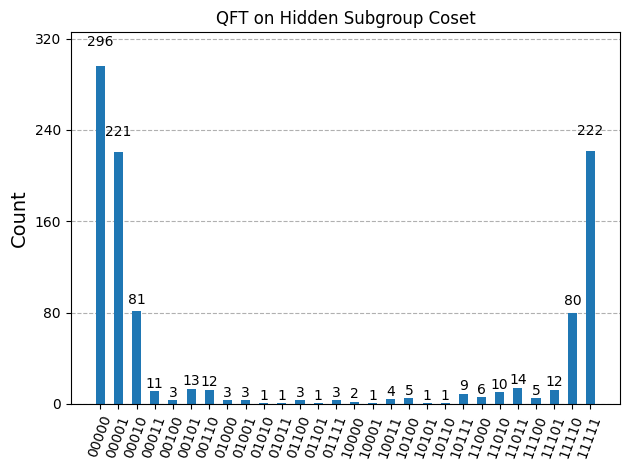

In [13]:
def subgroup_elements():
    return [(0, y, z) for y in range(3) for z in range(3)]

def coset_superposition(subgroup, shift, p=3):
    coset = [((shift[0] + g[0]) % p, (shift[1] + g[1]) % p, (shift[2] + g[2]) % p) for g in subgroup]
    N = len(coset)
    state = np.zeros(2**5, dtype=complex)
    for g in coset:
        idx = g[0]*9 + g[1]*3 + g[2]
        state[idx] = 1 / np.sqrt(N)
    return Statevector(state, dims=[2]*5)

subgroup = subgroup_elements()
ψ_coset = coset_superposition(subgroup, (1, 0, 0))
counts_coset = qft_measurement(ψ_coset)
plot_histogram(counts_coset, title="QFT on Hidden Subgroup Coset")


6️⃣ **EXPERIMENT 6: Manual Gate Count (No transpiler needed)**

In [14]:
def count_gates_qft(n):
    qc = QuantumCircuit(n)
    qc.append(QFT(n), range(n))
    counts = qc.count_ops()
    print(f"QFT-{n} Gate Counts:", counts)

count_gates_qft(5)
count_gates_qft(7)


QFT-5 Gate Counts: OrderedDict([('QFT', 1)])
QFT-7 Gate Counts: OrderedDict([('QFT', 1)])


7️⃣ **EXPERIMENT 7: Comparative Study Summary Code**

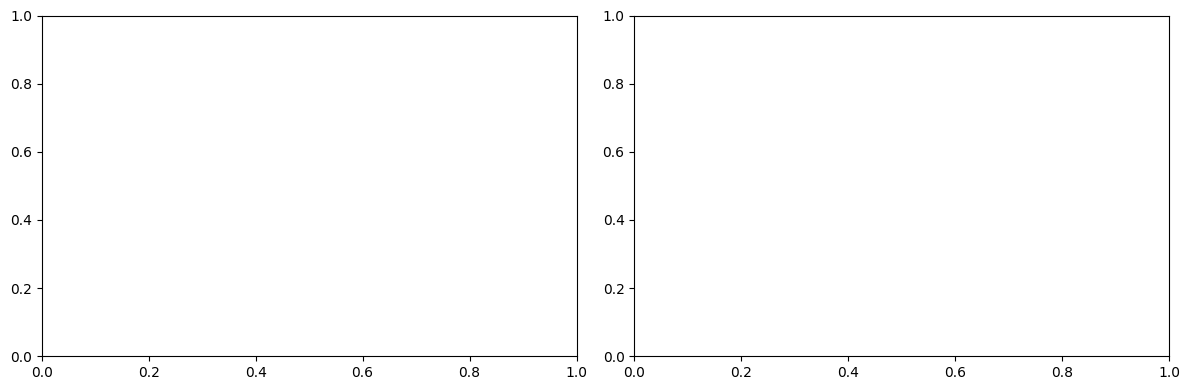

In [15]:
def compare_sampling(statevector, label=""):
    counts_clean = qft_measurement(statevector)
    noisy = inject_noise(statevector, bit_flip_prob=0.03, phase_flip_prob=0.03)
    counts_noisy = qft_measurement(noisy)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plot_histogram(counts_clean, title=f"Noiseless QFT - {label}", bar_labels=False)

    plt.subplot(1, 2, 2)
    plot_histogram(counts_noisy, title=f"Noisy QFT - {label}", bar_labels=False)
    plt.tight_layout()
    plt.show()

compare_sampling(ψ, label="H₃(Z₃) Class 1")
